# Class 1 - Phase identification - Single-Bus structure

## Agenda
- Problem Description
- Problem Implementation
- Alternative Problems
- Wrap-Up

## Problem Description

- While the connectivity model of low voltage (LV) grids is usually known, the phase connectivity information of single-phase connected customers is often erroneous or missing. This is due to many reasons including maintenance and other load balancing initiatives that usually do not update phase connectivity information and do not keep track of its changes in a systematic way.

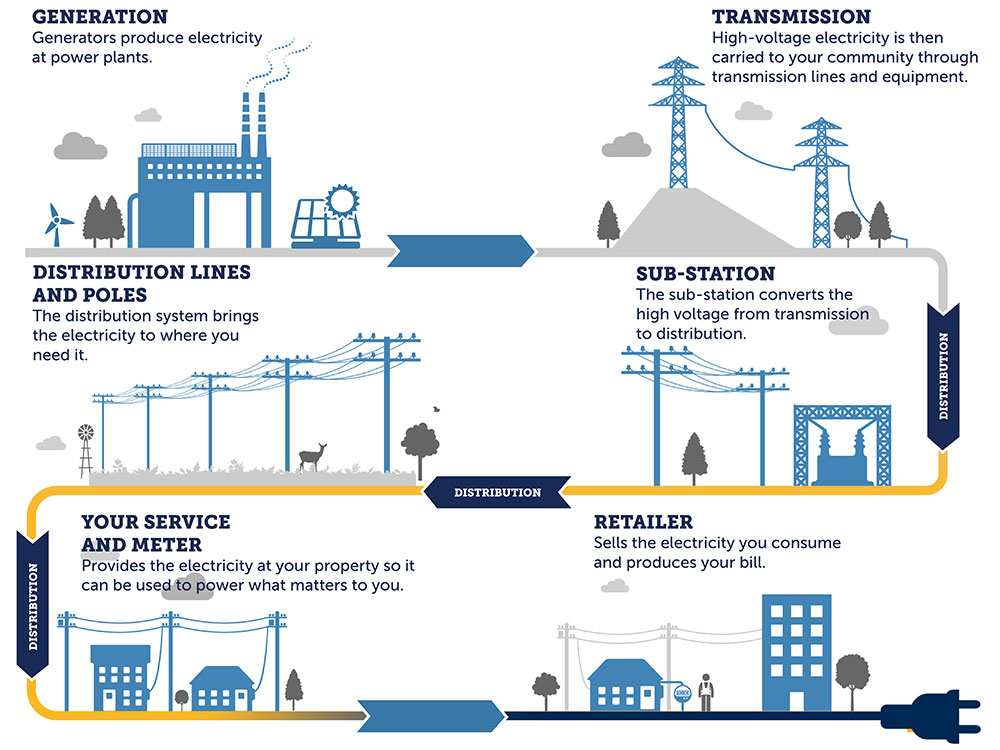
https://www.fortisalberta.com/about-us/our-company/blog/fortisalbertablog/2019/08/20/we-explain-the-complex-sophisticated-system-that-brings-electricity-to-you




- With the deployment of smart metering and the consequent availability
of high-resolution consumption data, phase connectivity
should be possible to estimate if data on per-phase aggregate energy
measurements would be available at substation sites with the
same resolutio.

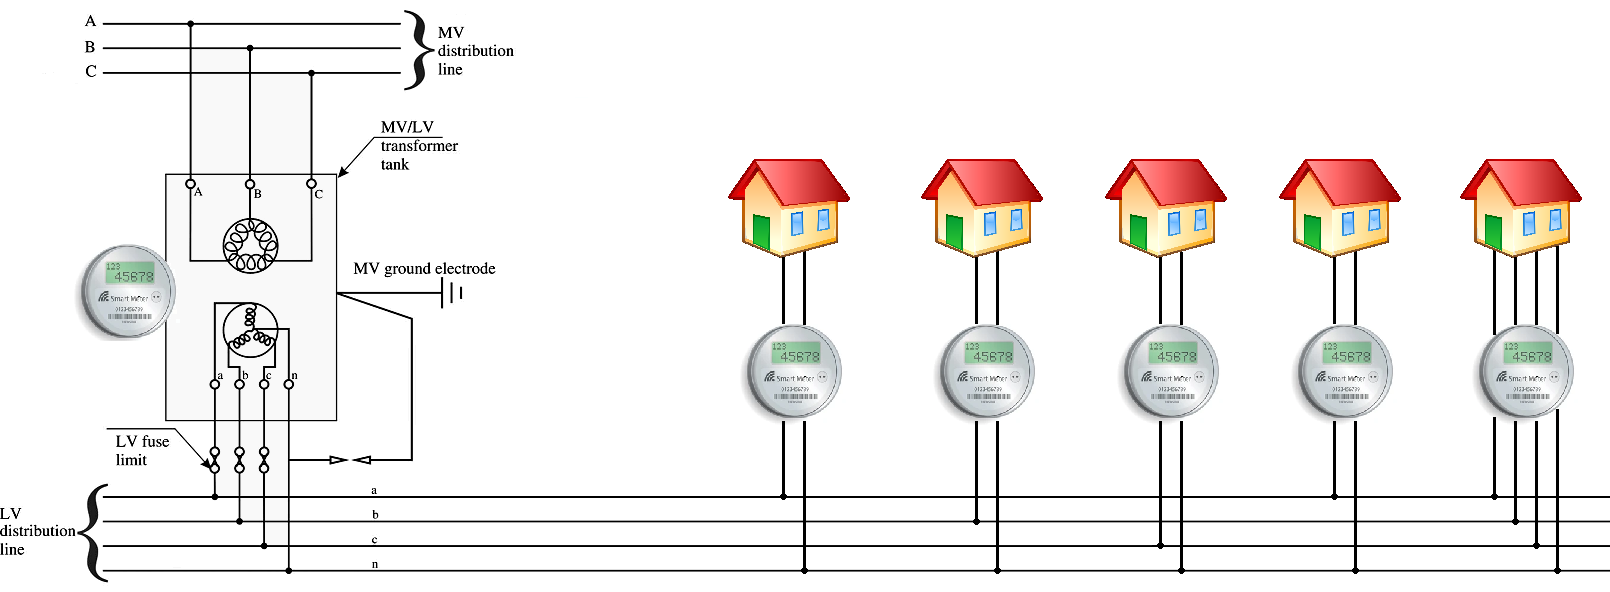

<b>Consider <i>N</i> customers whose connection phase assumes one out of three possible labels <i>a, b, </i> or <i> c</i> and estimate the correct customer-to-label assignment based on <i>M</i> readings whose per-phase values are a <i>function</i> of the corresponding phase-connected individual customer reading.</b>

## Problem Description

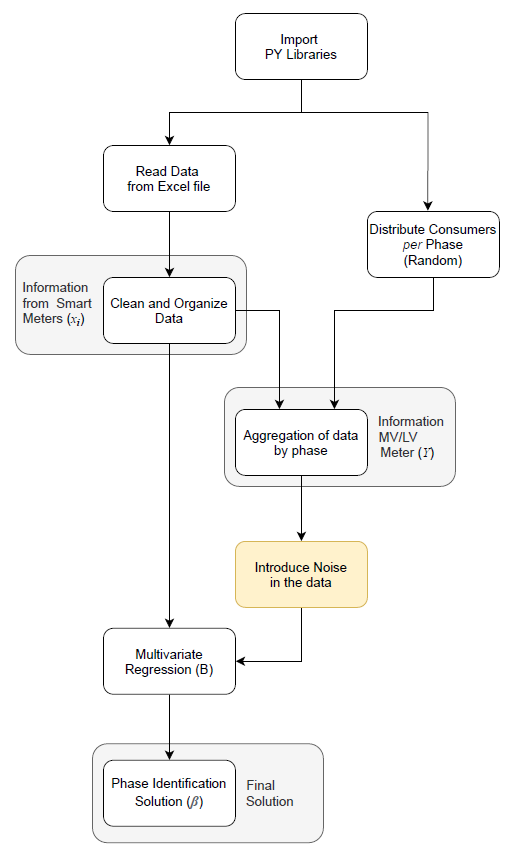

Import Python Libraries

In [201]:
import pandas as pd
import numpy as np
from numpy.random import randint   # To random values in the phases
from numpy.random import random   # To random values in the phases
import matplotlib.pyplot as plt
from numpy.linalg import inv


Parameters (It is possible to change to test different input data)

In [202]:
nc=4                        # Number of consumers (1 to nc)                  %%Data Notes: nc=4
ts=60                       #start period of analysis (Can be from 1 to 96)  %%Data Notes: ts=60
te=71                       #Last period of analysis (Can be from 1 to 96)   %%Data Notes: te=71
phase =[3,2,1,3]            #To obtain the same values of lecture notes
noise = 0
#phase = randint(1, 4, nc)  #To obtain random values

eps_error=0.01  # Error with variance 0.01

print ("The distribution of consumers in each phase is: ", phase)

The distribution of consumers in each phase is:  [3, 2, 1, 3]


Import data (From Excel file)

In [203]:
raw_data = np.array(pd.read_excel ('Prob1_Conso_Data.xlsx', header=None))

Clean and organize the data (delete zeros and organize by consumers)

In [204]:
checks=0
nr=1
data=np.zeros((1,96))
#h=np.arange(1/96, 1, 1/96).tolist()
h=raw_data[0:96,0]
for i in range(1,raw_data.shape[0]+1):
    if i==0:
        print(i)
    if raw_data[i-1,0]==h[checks]:
        checks=checks+1
    else:
        checks=0
    if checks==96:
        if np.sum(raw_data[i-96:i,1])!=0:
            data[nr-1,0:96]=raw_data[i-96:i,1]
            data.resize((nr+1,96))
            nr=nr+1
        checks=0
data.resize((nr-1,96))

data.shape[0]      #Can be deleted
print ("The number of consumers is ", data.shape[0], " and the number of periods is ", data.shape[1])

The number of consumers is  1390  and the number of periods is  96


Select data from consumers and period (Truncate the original matrix) 

In [205]:
data_Aux1=data[0:nc,:]
pw=data_Aux1[:,ts-1:te]

print ("The matrix 'pw' represents the power measured by the smart meter in each consumer (i) in each period (k)")
print ("In the lecture notes, this value is represented by X.")
print ("The value of X is:\n",np.transpose(4*pw))   # We should multiply by 4 to obtain the same values of the lectures. 
                                                    # In fact the original values are the average energy consumption for
                                                    # 15 minutes. To obtain the power, we should multiply by 4  


The matrix 'pw' represents the power measured by the smart meter in each consumer (i) in each period (k)
In the lecture notes, this value is represented by X.
The value of X is:
 [[0.332 0.064 0.084 0.12 ]
 [0.236 0.164 0.276 0.064]
 [0.224 0.708 1.572 0.072]
 [0.36  3.44  1.188 0.18 ]
 [1.332 2.176 0.484 1.464]
 [1.516 3.02  0.316 0.624]
 [0.92  0.916 0.404 2.772]
 [0.752 0.64  0.396 1.464]
 [1.828 0.684 0.576 0.576]
 [3.568 0.564 0.828 0.428]
 [0.78  0.356 0.728 0.348]
 [0.856 0.22  0.308 0.12 ]]


Consumers aggregation by phase and noise inclusion (normal distribution).

In [206]:
# Here I assume that we need to consider the values of the phases and then add noise to then try solving the problem for the phases we originally set
# This is a bit redundant, but it can be useful to understand the problem and the solution.
X = np.transpose(4*pw)
Y = np.zeros((X.shape[0], 3))  # To store the sum of the power in each phase and period

for k in range(X.shape[0]):
    for i in range(len(phase)):
        target_phase = phase[i] 
        phase_id = target_phase - 1
        
        eps=np.random.normal(1, size=[1,1])*eps_error 

        Y[k, phase_id] += X[k, i] + eps

print(X.shape[0])
print(Y)

12
[[0.08647568 0.05867396 0.4741828 ]
 [0.27508654 0.17084755 0.31138474]
 [1.57332181 0.69888671 0.30555142]
 [1.18850348 3.44706931 0.53451556]
 [0.48348653 2.19134808 2.79597681]
 [0.31576344 3.0291698  2.16871082]
 [0.42753669 0.93036637 3.73332807]
 [0.39586397 0.64487845 2.24927182]
 [0.5752078  0.69694642 2.43313259]
 [0.83405652 0.57171081 3.98855192]
 [0.7361338  0.34305052 1.1295408 ]
 [0.32359265 0.23149924 1.00553764]]


C:\Users\User\AppData\Local\Temp\ipykernel_6192\3109204974.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y[k, phase_id] += X[k, i] + eps


Multivariate Regression 

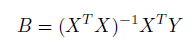

In [207]:
# Ordinarily squared solves the linear system and we get the beta matrix

beta = inv(X.transpose() @ X) @ X.transpose() @ Y

print(beta)

[[ 5.23359654e-04  3.40553623e-03  1.00088710e+00]
 [-2.24740618e-03  1.00323350e+00 -8.04808454e-04]
 [ 1.00329430e+00 -7.63735524e-03  2.60549923e-03]
 [ 5.80986969e-03  3.67720719e-03  1.01463098e+00]]


First of all, I want to make a function that approximates the $\beta$ function to a matrix with only zeros and ones and checks if the phases match with the original phase vector.

In [208]:
beta_perfect = beta.copy()
phases_result = np.array([0]*beta_perfect.shape[0])


for k in range(beta_perfect.shape[0]):
    max_idx = np.argmax(beta_perfect[k, :])
    phases_result[k] = max_idx + 1
    beta_perfect[k, :] = 0
    beta_perfect[k, max_idx] = 1

print(beta_perfect)
print("Resulting phases vector:" + str(phases_result))

# This returns a single True or False
are_identical = np.array_equal(phases_result, phase)

if are_identical:
    print("The phases match.")
else:
    print("The phases do not match.")

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]
Resulting phases vector:[3 2 1 3]
The phases match.


Plot

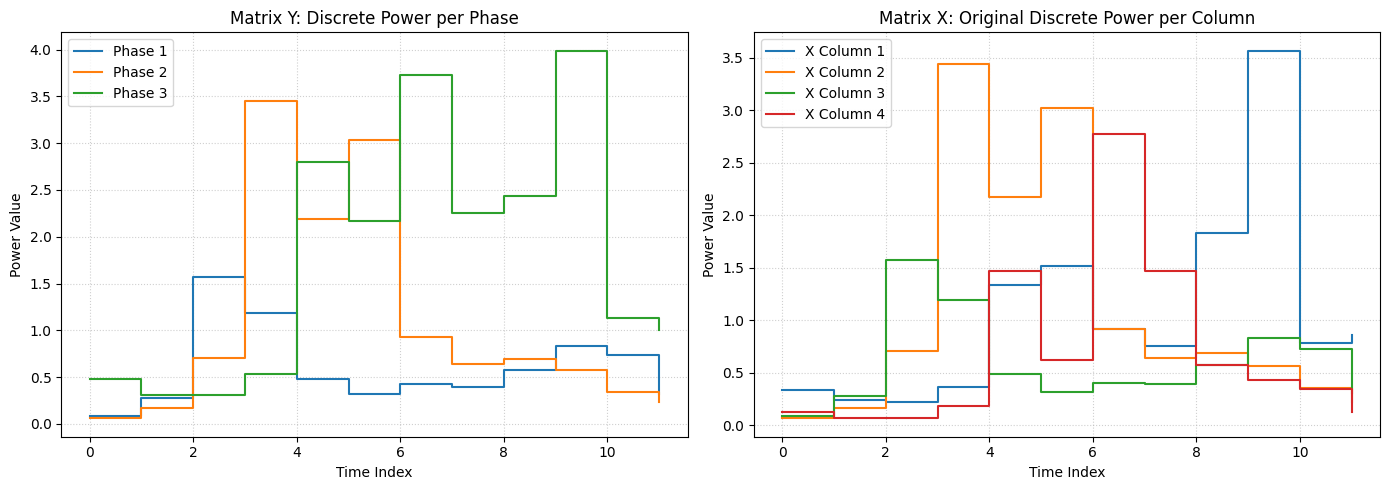

In [209]:
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Matrix Y (Left Side) ---
for i in range(Y.shape[1]):
    ax1.step(np.arange(Y.shape[0]), Y[:, i], where='post', label=f'Phase {i+1}')

ax1.set_title('Matrix Y: Discrete Power per Phase')
ax1.set_xlabel('Time Index')
ax1.set_ylabel('Power Value')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Matrix X (Right Side) ---
for i in range(X.shape[1]):
    ax2.step(np.arange(X.shape[0]), X[:, i], where='post', label=f'X Column {i+1}')

ax2.set_title('Matrix X: Original Discrete Power per Column')
ax2.set_xlabel('Time Index')
ax2.set_ylabel('Power Value')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

# Adjust layout so titles/labels don't overlap
plt.tight_layout()
plt.show()

# Extra Challenges
Think about an interesting variation to this problem or a different way to solve and implement it !!!

Some ideas:
- What happens if we have two consumers with the same consumption ? What about if the difference is very small ? Can we quantify the sensitivity ?
- What happens if we have three-phase clients ? Can we follow the same approach ?

First let's create a function that generates X, Y and calculates $\beta$ depending on inputs:

(this is just what was done above put into a function that returns True or False depending on wether the input phase vector and created phase vectors match)

In [210]:
def full_solve(nc, ts, te, phase, eps_error, data=data):
    data_Aux1=data[0:nc,:]
    pw=data_Aux1[:,ts-1:te]
    X = np.transpose(4*pw)

    Y = np.zeros((X.shape[0], 3))  # To store the sum of the power in each phase and period

    for k in range(X.shape[0]):
        for i in range(len(phase)):
            target_phase = phase[i] 
            phase_id = target_phase - 1
            
            eps = np.random.normal(1) * eps_error

            Y[k, phase_id] += X[k, i] + float(eps)
    
    beta = inv(X.transpose() @ X) @ X.transpose() @ Y

    beta_perfect = beta.copy()
    phases_result = np.array([0]*beta_perfect.shape[0])


    for k in range(beta_perfect.shape[0]):
        max_idx = np.argmax(beta_perfect[k, :])
        phases_result[k] = max_idx + 1
        beta_perfect[k, :] = 0
        beta_perfect[k, max_idx] = 1

    # This returns a single True or False
    are_identical = np.array_equal(phases_result, phase)

    return are_identical

def calculate_accuracy(test_func, iterations=100):
    # Run the passed-in function and store results as booleans
    results = [test_func() for _ in range(iterations)]
    
    # Calculate percentage
    accuracy = np.mean(results) * 100
    return accuracy


def test_variable_time(current_nc, eps_error, random_clients=False):
    if random_clients:
        current_nc = np.random.randint(1, current_nc)
    
    new_phase = np.random.randint(1, 4, current_nc)
    
    limit = 96 - current_nc
    new_ts = np.random.randint(1, max(2, limit)) 
    

    low_te = new_ts + current_nc
    high_te = max(low_te + 1, 97)
    new_te = np.random.randint(low_te, high_te)
    
    return full_solve(current_nc, new_ts, new_te, new_phase, eps_error)

### Varying Levels of Noise and Clients

In this section we'll vary the noise levels and see how it impacts the system. We will also vary the amount of clients.

Check sensitivity to noise with 4 clients and 12 points.

In [211]:
new_eps_error = np.random.random() * 0.5

# We define what one single test run looks like
test_noise = lambda: full_solve(nc, ts, te, phase, new_eps_error)

accuracy = calculate_accuracy(test_noise, iterations=100)
print(f"Accuracy with random noise: {accuracy}%")   

Accuracy with random noise: 100.0%


Now let's see how this sensitivity varies as the number of clients increases.

In [212]:
for i in range(12 - nc):
    current_nc = nc + i
    # Define a test for this specific number of consumers
    test_scale = lambda: full_solve(current_nc, ts, te, np.random.randint(1, 4, current_nc), eps_error)
    
    accuracy = calculate_accuracy(test_scale, iterations=100)
    print(f"Consumers: {current_nc} | Accuracy: {accuracy}%")

Consumers: 4 | Accuracy: 100.0%
Consumers: 5 | Accuracy: 100.0%
Consumers: 6 | Accuracy: 100.0%
Consumers: 7 | Accuracy: 61.0%
Consumers: 8 | Accuracy: 36.0%
Consumers: 9 | Accuracy: 26.0%
Consumers: 10 | Accuracy: 25.0%
Consumers: 11 | Accuracy: 22.0%


As we can see the reliability greatly decreases as the number of clients goes up. But what if we increase the number of sample points too, from 12 to 55?

In [213]:
for i in range(12 - nc):
    current_nc = nc + i
    ts = 1
    te = 55
    # Define a test for this specific number of consumers
    test_scale = lambda: full_solve(current_nc, ts, te, np.random.randint(1, 4, current_nc), eps_error)
    
    accuracy = calculate_accuracy(test_scale, iterations=100)
    print(f"Consumers: {current_nc} | Accuracy: {accuracy}%")

Consumers: 4 | Accuracy: 100.0%
Consumers: 5 | Accuracy: 100.0%
Consumers: 6 | Accuracy: 100.0%
Consumers: 7 | Accuracy: 100.0%
Consumers: 8 | Accuracy: 100.0%
Consumers: 9 | Accuracy: 100.0%
Consumers: 10 | Accuracy: 100.0%
Consumers: 11 | Accuracy: 100.0%


And now setting a random time interval:

In [214]:
for i in range(12 - nc):
    current_nc = nc + i
    
    # We wrap our logic above into a simple call for the calculator
    accuracy = calculate_accuracy(lambda: test_variable_time(current_nc, eps_error), iterations=1000)
    
    print(f"Consumers: {current_nc} | Accuracy: {accuracy:.2f}% (Across 1000 random time windows)")

Consumers: 4 | Accuracy: 99.90% (Across 1000 random time windows)
Consumers: 5 | Accuracy: 99.10% (Across 1000 random time windows)
Consumers: 6 | Accuracy: 98.60% (Across 1000 random time windows)
Consumers: 7 | Accuracy: 80.00% (Across 1000 random time windows)
Consumers: 8 | Accuracy: 74.70% (Across 1000 random time windows)
Consumers: 9 | Accuracy: 75.10% (Across 1000 random time windows)
Consumers: 10 | Accuracy: 74.70% (Across 1000 random time windows)
Consumers: 11 | Accuracy: 70.80% (Across 1000 random time windows)


Now a last analysis, randomzing everything, even the number of clients (from 1-20):

In [215]:
accuracy = calculate_accuracy(lambda: test_variable_time(20, eps_error, True), iterations=4000)
    
print(f"Accuracy: {accuracy:.2f}% (Across 4000 random time windows, errors and clients)")

Accuracy: 81.10% (Across 4000 random time windows, errors and clients)


### Two clients with the same consumption

Now we'll study what happens when there are two or more clients with the same consumption. For this we can build a new X matrix:

